In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay
 
from sklearn.svm import SVC, SVR
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.utils.class_weight import compute_class_weight

import scipy.stats as stats 
import os

In [3]:
train_filename = "../data/training1109.xlsx"
save_dir="./dist"

## Read Data

In [4]:
def readExcel(filename, sheet_name="Sheet1", usecols=None):
    df=pd.read_excel(io=filename,sheet_name=sheet_name, usecols=usecols)
    nullIndexs = np.where((df.isnull()).values)
    return df.values, list(df.columns), nullIndexs


def getFeatures(values, headers, usedHeaders=None, dtype="float32"):
    if usedHeaders is None:
        return values
    usedHeaderIndexs = [headers.index(h) for h in usedHeaders]
    data = np.array(values[:,usedHeaderIndexs], dtype=dtype)
    return data

def getLabels(values, headers, labelHeader=None, dtype="int"):
    if labelHeader is None:
         raise Exception(f"必须指定labelHeader参数")
    labelHeaderIdx = headers.index(labelHeader)
    labels = np.array(values[:,labelHeaderIdx], dtype=dtype)
    return labels 

In [5]:
values, headers, nullIndexs = readExcel(train_filename)
rmRowIndexs = list(set(list(nullIndexs[0])))

- 含有 nan 值特征的行删除
- 原表 587 行 scr.pre 异常。对应索引为585

In [6]:
rmRowIndexs+=[585]
print(len(rmRowIndexs))

129


In [7]:
# 全部变量
usedHeaders = ["sex","age","height","weight","bmi","smoke",
               "hp","dm","chd","arrhy","copd","pad","rf","chemo",
               "radio","pn","picc","sbp.pre","dbp.pre","hr.pre",
               "plt.pre","plt.post","hb.pre","hb.post","alb.pre",
               "alb.post","tbil.pre","tbil.post","wbc.pre","wbc.post",
               "alt.pre","alt.post","scr.pre","scr.post","asa","bleed",
               "trans.surg","trans.post","icu","los.icu","scopy","open",
               "scopy.open","stoma","class.surg.t1"
              ]

In [8]:
dtype = "float64"
all_features = getFeatures(values, headers, usedHeaders=usedHeaders, dtype=dtype)
all_features = np.delete(all_features,rmRowIndexs,0)
print(all_features.shape, all_features.dtype)
print(all_features)

(2368, 45) float64
[[ 1.   63.    1.59 ...  0.    0.    2.  ]
 [ 0.   21.    1.65 ...  0.    0.    3.  ]
 [ 1.   57.    1.78 ...  1.    0.    1.  ]
 ...
 [ 0.   59.    1.6  ...  0.    0.    1.  ]
 [ 0.   63.    1.58 ...  0.    0.    2.  ]
 [ 1.   58.    1.72 ...  0.    0.    2.  ]]


In [9]:
all_labels = getLabels(values, headers, labelHeader="ssi.bin", dtype="int")
all_labels = np.delete(all_labels,rmRowIndexs,0)
print(all_labels.shape, all_labels.dtype)
print(all_labels)

(2368,) int64
[0 0 0 ... 0 0 0]


### 变量处理

In [10]:
# 筛选的连续变量
headers_1 = ["sex","age","height","weight","bmi","bleed","trans.surg","trans.post"]

# 筛选的分类变量
headers_2 = ["smoke","hp","dm","chd","arrhy","copd","pad",
             "rf","chemo","radio","pn","picc","asa","icu","los.icu",
             "scopy","open","scopy.open","stoma","class.surg.t1"
            ]
             
# 筛选的术前术后变量
headers_3 = ["sbp.pre","dbp.pre","hr.pre",
             "plt.pre","plt.post","hb.pre","hb.post","alb.pre",
             "alb.post","tbil.pre","tbil.post","wbc.pre","wbc.post",
             "alt.pre","alt.post","scr.pre","scr.post"
            ]

print(len(headers_1)+len(headers_2)+len(headers_3)==len(usedHeaders))

True


In [11]:
"""
ctype:
  - both 取术前和术后
  - pre 只取术前
  - post 只取术后
  - rate 术后/术前
  - change 术后-术前
  - ratio (术后-术前)/术前 * 100
islog 是否取对数
"""
def calcPrePost(features, ctype="post", islog=False):
    pre = features[:,0]
    post = features[:,1]
    res=None
    if ctype=="both":
        res = np.empty((features.shape[0],2))
        res[:,0]=pre
        res[:,1]=post
    elif ctype=="pre":
        res = pre
        res = res.reshape((-1,1))
    elif ctype=="post":
        res = post
        res = res.reshape((-1,1))
    elif ctype=="rate":
        res = post/pre
        res = res.reshape((-1,1))
    elif ctype=="change":
        res = post-pre
        res = res.reshape((-1,1))
    elif ctype=="ratio":
        res = 100* (post-pre)/pre
        res = res.reshape((-1,1))
    else:
        res = features
    
    return np.log(res) if islog else res

In [12]:
var_one = [
    {"key":"weight","rename":"weight"},
    {"key":"copd","rename":"copd"},
    {"key":"pad", "rename":"pad"},
    {"key":"picc","rename":"picc"},
    {"key":"icu","rename":"icu"},
    {"key":"los.icu","rename":"icuG1"},
    {"key":"scopy.open","rename":"scopy2open"},
    {"key":"stoma","rename":"stoma"},
    {"key":"bleed","func":lambda fea: 1*(fea>500),"rename":"bleedG500"},
    {"key":"class.surg.t1","rename":"surgClass"}
]
var_pre_post = [
    {"pre":"wbc.pre","post":"wbc.post","ctype":"post","islog":True,"rename":"WBCPostLog"},
    {"pre":"plt.pre","post":"plt.post","ctype":"change","islog":False,"rename":"PltChange"},
    {"pre":"hb.pre","post":"hb.post","ctype":"change","islog":False,"rename":"HbChange"},
    {"pre":"alb.pre","post":"alb.post","ctype":"post","islog":False,"rename":"AlbPost"},
    {"pre":"alt.pre","post":"alt.post","ctype":"rate","islog":True,"rename":"AltRateLog"},
    {"pre":"scr.pre","post":"scr.post","ctype":"rate","islog":False,"rename":"ScrRate"},
]

In [13]:
fea_1 = None
fea_1_names = []
select_1_columns = []
for pair in var_pre_post:
    columns = [usedHeaders.index(pair["pre"]), usedHeaders.index(pair["post"])]
    select_1_columns += [usedHeaders.index(pair["pre"]), usedHeaders.index(pair["post"])]
    fea = calcPrePost(
        all_features[:,columns], 
        ctype=pair["ctype"],
        islog=pair["islog"]
    )
    fea_1 = fea if fea_1 is None else np.concatenate([fea_1,fea],axis=1)
    if fea.shape[1]>1:
        fea_1_names.append(pair["rename"]+"-pre")
        fea_1_names.append(pair["rename"]+"-post")
    else:
        fea_1_names.append(pair["rename"])

In [14]:
fea_2 = None
fea_2_names = []
select_2_columns = []
for key_func in var_one:
    if not "func" in key_func:
        column = usedHeaders.index(key_func["key"])
        fea = all_features[:,column].reshape((-1,1))
    else:
        key = key_func["key"]
        func = key_func["func"]
        column = usedHeaders.index(key)
        fea = all_features[:,column]
        fea = func(fea).reshape((-1,1))
    select_2_columns += [column]    
    fea_2 = fea if fea_2 is None else np.concatenate([fea_2,fea],axis=1)
    if fea.shape[1]>1:
        fea_2_names.append(key_func["rename"]+"-pre")
        fea_2_names.append(key_func["rename"]+"-post")
    else:
        fea_2_names.append(key_func["rename"])

### Split Data

In [15]:
from sklearn.model_selection import train_test_split

test_size=0.3
all_selected_features = np.concatenate([fea_1,fea_2],axis=1)
all_selected_fea_nams = fea_1_names + fea_2_names
select_columns = select_1_columns + select_2_columns
fea_nums = all_selected_features.shape[1]
print(len(all_selected_fea_nams)==fea_nums)
train_features, test_features, train_labels, test_labels = train_test_split(all_selected_features, all_labels, test_size=test_size, random_state=123, stratify=all_labels)
print(train_features.shape, test_features.shape, train_labels.shape, test_labels.shape)

True
(1657, 16) (711, 16) (1657,) (711,)


# 朴素贝叶斯分类器

In [16]:
p = train_labels.sum() / len(train_labels)
p_probas = [1-p,p]  # [p(θ=0), p(θ=1)]
print(p_probas)

[0.8654194327097163, 0.13458056729028364]


In [17]:
rowIndexs_1 = np.where(train_labels==1)[0]
rowIndexs_0 = np.where(train_labels==0)[0]
train_maxvalues_1 = np.max(np.abs(train_features[rowIndexs_1,:]),axis=0)
train_maxvalues_0 = np.max(np.abs(train_features[rowIndexs_0,:]),axis=0)
train_maxvalues = np.max(np.abs(train_features),axis=0)

In [19]:
np.savetxt(os.path.join(save_dir,"maxvalues.txt"), train_maxvalues)

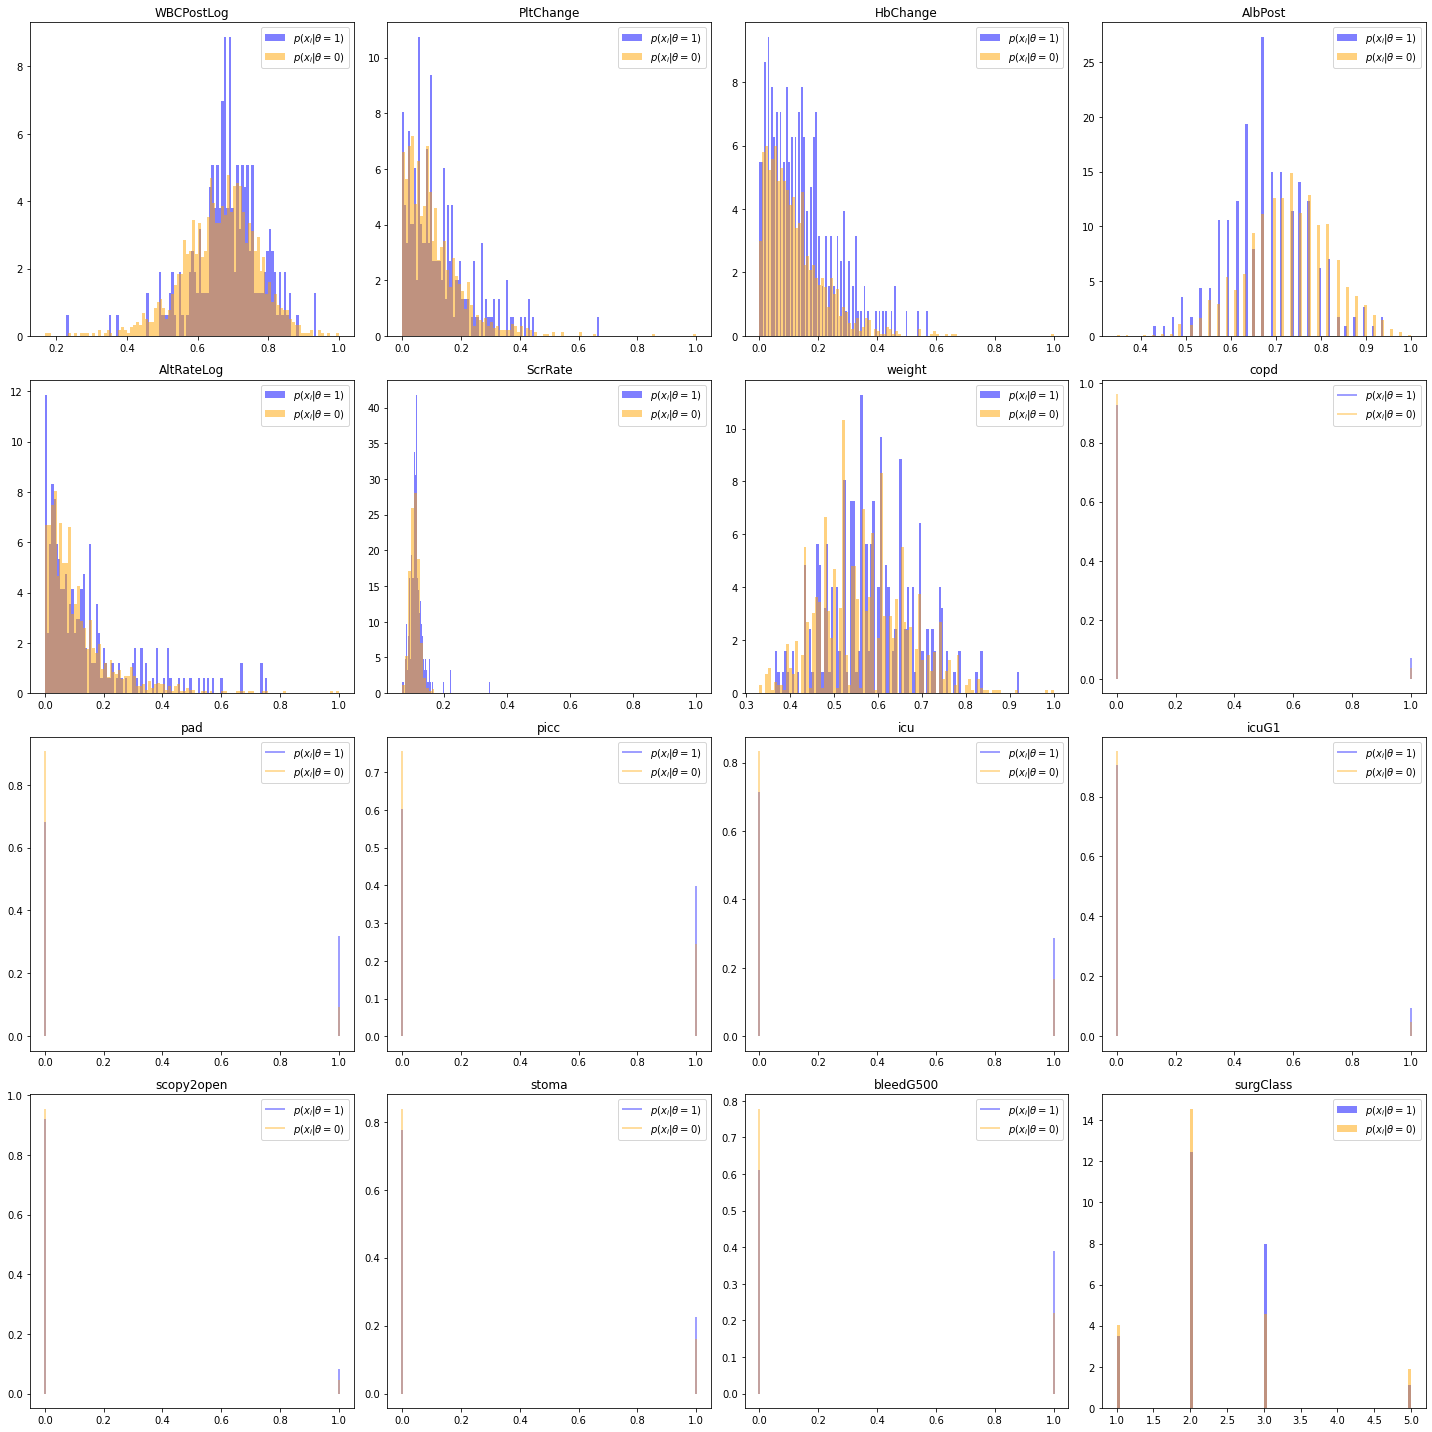

In [20]:
plt.figure(figsize=(4*5,4*5))
for i in range(fea_nums):
    plt.subplot(4,4,i+1)
    x_theta_1 = train_features[rowIndexs_1,i]
    x_theta_0 = train_features[rowIndexs_0,i]
    isNorm = i<7
    if isNorm:
        x_theta_1 = np.abs(x_theta_1)
        x_theta_0 = np.abs(x_theta_0)
        x_theta_1 /= train_maxvalues[i]
        x_theta_0 /= train_maxvalues[i]
    
    if (i>=7 and i<=14):
        x = [0,1]
        p_1 = x_theta_1.sum()/len(x_theta_1)
        p_0 = x_theta_0.sum()/len(x_theta_0)
        plt.vlines(x,[0,0],[1-p_1,p_1],label=r"$p(x_i|\theta=1)$",alpha=0.5,color="blue")
        plt.vlines(x,[0,0],[1-p_0,p_0],label=r"$p(x_i|\theta=0)$",alpha=0.5,color="orange")
    else:
        plt.hist(x_theta_1,bins=100,label=r"$p(x_i|\theta=1)$",alpha=0.5,density=True,color="blue")
        plt.hist(x_theta_0,bins=100,label=r"$p(x_i|\theta=0)$",alpha=0.5,density=True,color="orange")
        
    plt.title(all_selected_fea_nams[i])
    plt.legend()
    
plt.tight_layout()
plt.show()

In [21]:
def beta_pdf(α,β,loc,scale):
    def plot(x):
        return stats.beta.pdf(x,α,β,loc,scale)
    return plot

def expon_pdf(loc, scale):
    def plot(x):
        return stats.expon.pdf(x,loc,scale)
    return plot

def fit_beta(x):
    return stats.beta.fit(x)

def fit_expon(x):
    return stats.expon.fit(x)

(6.470848703532094, 16.63153423979494, 0.25263132774750563, 1.1193147100343035)
6.470848703532094 16.63153423979494


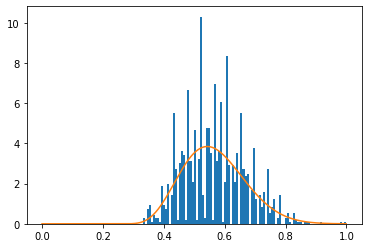

In [22]:
observed_data = np.abs(train_features[rowIndexs_0,6]) / train_maxvalues[6]

print(stats.beta.fit(observed_data))
(α,β,loc,scale)=stats.beta.fit(observed_data)

plt.hist(observed_data,bins=100,density=True)
x_ = np.arange(0,1,0.001)
pre_data = stats.beta.pdf(x_, α, β,loc,scale)
plt.plot(x_, pre_data)
print(α,β)

In [23]:
fit_models = [
    [fit_beta,beta_pdf],
    [fit_expon,expon_pdf],
    [fit_expon,expon_pdf],
    [fit_beta,beta_pdf],
    [fit_expon,expon_pdf],
    [fit_beta,beta_pdf],
    [fit_beta,beta_pdf]
]

In [37]:
model_and_traces_0 = []
model_and_traces_1 = []

traces_0 = []
traces_1 = []

/root/miniconda3/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:709: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/root/miniconda3/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


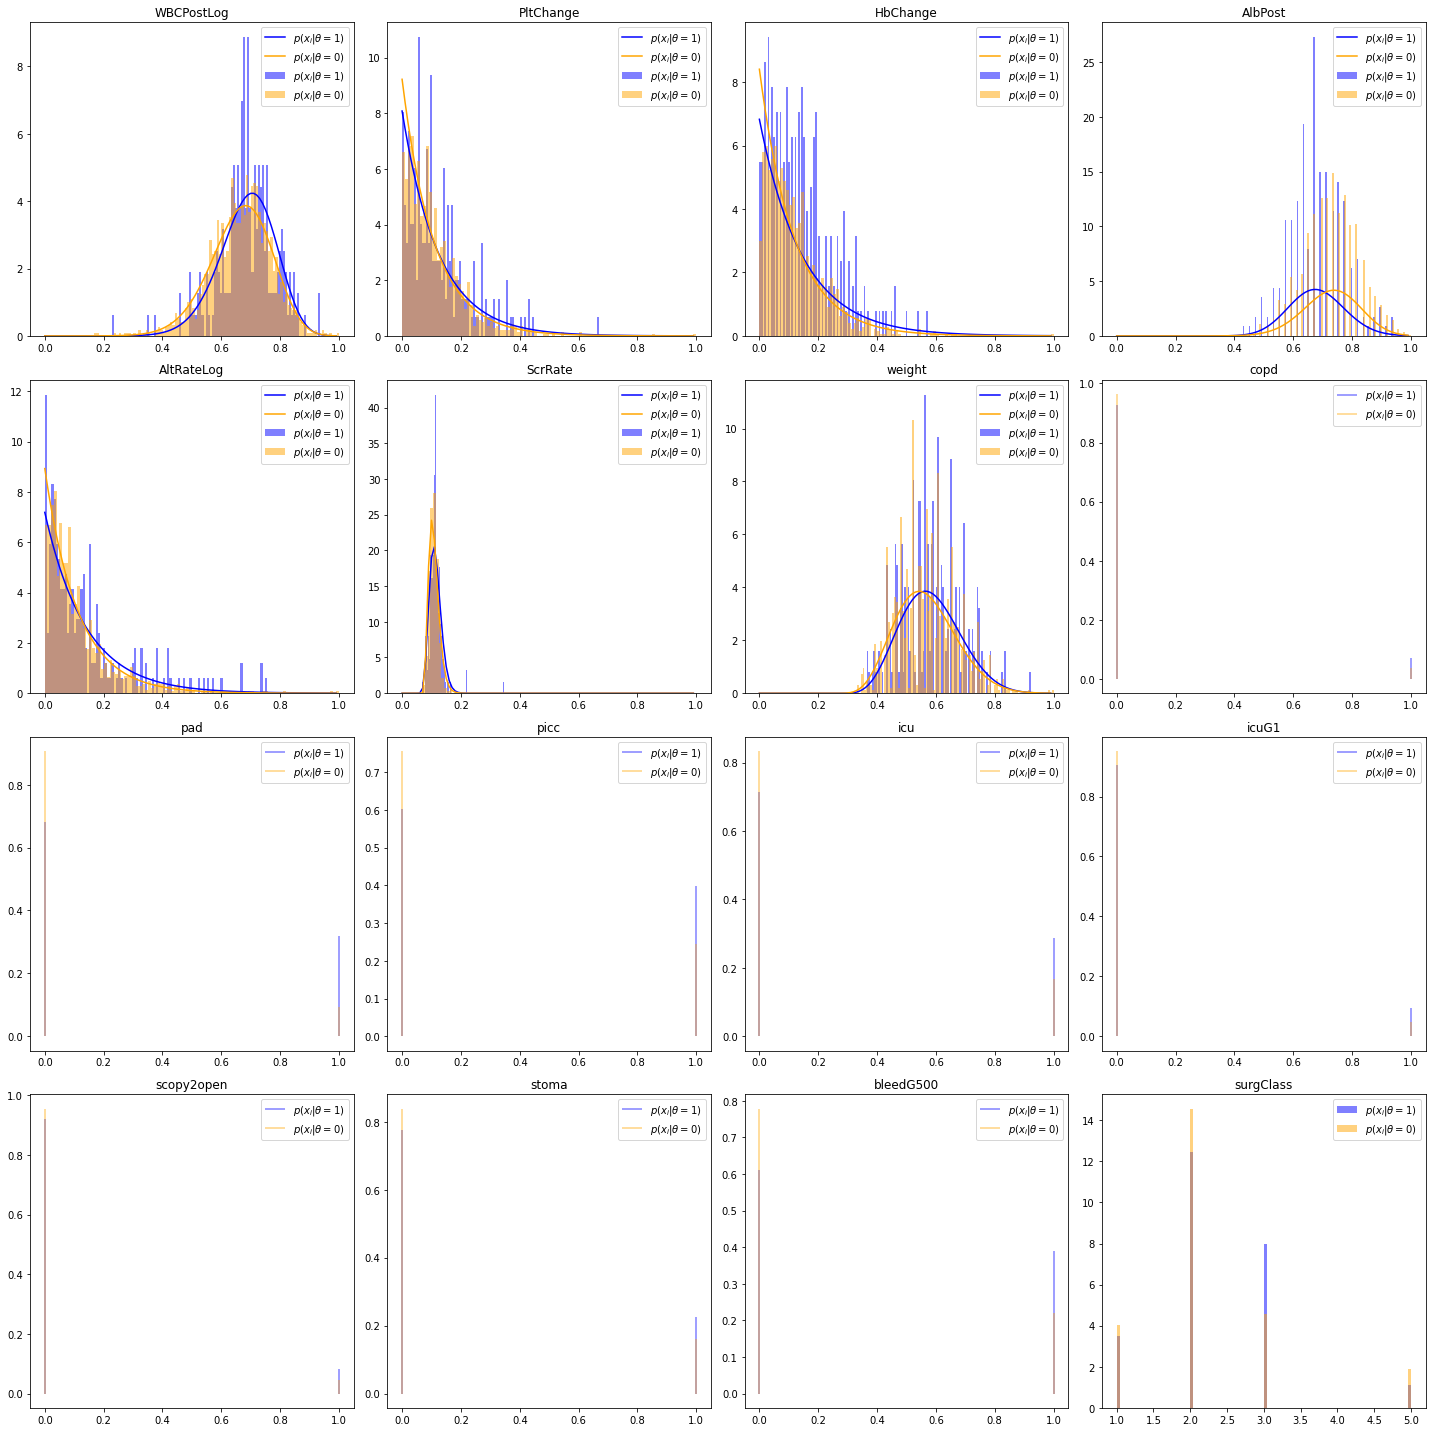

In [38]:
plt.figure(figsize=(4*5,4*5))
for i in range(fea_nums):
    plt.subplot(4,4,i+1)
    x_theta_1 = train_features[rowIndexs_1,i]
    x_theta_0 = train_features[rowIndexs_0,i]
    isNorm = i<7
    if isNorm:
        x_theta_1 = np.abs(x_theta_1)
        x_theta_0 = np.abs(x_theta_0)
        x_theta_1 /= train_maxvalues[i]
        x_theta_0 /= train_maxvalues[i]
        
        fit_m, pdf_m = fit_models[i]
        fit_1_res = fit_m(x_theta_1)
        traces_1.append(fit_1_res)

        fit_0_res = fit_m(x_theta_0)
        traces_0.append(fit_0_res)
        
        plot_1 = pdf_m(*fit_1_res)
        plot_0 = pdf_m(*fit_0_res)
        
        model_and_traces_0.append(plot_0)
        model_and_traces_1.append(plot_1)

        x=np.arange(0,1,0.01)
        y_0 = plot_0(x)
        y_1 = plot_1(x)
        plt.plot(x,y_1,label=r"$p(x_i|\theta=1)$",color="blue")
        plt.plot(x,y_0,label=r"$p(x_i|\theta=0)$",color="orange")
    
    if (i>=7 and i<=14):
        x = [0,1]
        p_1 = x_theta_1.sum()/len(x_theta_1)
        p_0 = x_theta_0.sum()/len(x_theta_0)
        plt.vlines(x,[0,0],[1-p_1,p_1],label=r"$p(x_i|\theta=1)$",alpha=0.5,color="blue")
        plt.vlines(x,[0,0],[1-p_0,p_0],label=r"$p(x_i|\theta=0)$",alpha=0.5,color="orange")
    else:
        plt.hist(x_theta_1,bins=100,label=r"$p(x_i|\theta=1)$",alpha=0.5,density=True,color="blue")
        plt.hist(x_theta_0,bins=100,label=r"$p(x_i|\theta=0)$",alpha=0.5,density=True,color="orange")
        
    plt.title(all_selected_fea_nams[i])
    plt.legend()
    
plt.tight_layout()
# plt.show()
# plt.savefig("/kaggle/working/fea_dis.jpg")

In [39]:
def plot_feature(k,feature, trace):
    p_dict={}
    for k_ in k:
        p_dict[k_] = len(np.where(feature==k_)[0]) / len(feature)
    trace.append(p_dict)
    def plot(x):
        return p_dict[x]
    return plot
for i in range(7,16):
    k = np.unique(train_features[:,i])
    model_and_traces_0.append(plot_feature(k,train_features[rowIndexs_0,i], traces_0))
    model_and_traces_1.append(plot_feature(k,train_features[rowIndexs_1,i], traces_1))

In [40]:
np.save(os.path.join(save_dir, "traces_1"),np.array(traces_1,dtype="object"))
np.save(os.path.join(save_dir, "traces_0"),np.array(traces_0,dtype="object"))

# Model Assement

In [41]:
# p(x_i|θ=j) = 
# likehood_probas[j,i]
# plot(x_i)
likehood_probas = np.array([
    model_and_traces_0,
    model_and_traces_1,
],dtype="object")
print(likehood_probas.shape)

# p(θ=j)=p_probas[j]

(2, 16)


In [42]:
np.savetxt(os.path.join(save_dir, "p_probas.txt"), p_probas)

In [43]:
def prediction_probas(features, fea_range=range(16)):
    n,m = features.shape
    probas = np.empty((n,2))
    for k in range(n):
        for i in range(2):
            p = p_probas[i]
            for j in fea_range:
                isNorm=j<7
                plot = likehood_probas[i,j]
                fea_input = abs(features[k,j]) / train_maxvalues[j] if isNorm else features[k,j]
                p_ = plot(fea_input)
                p*=p_
            probas[k,i]=p
    return probas / (probas.sum(axis=1).reshape((-1,1))+1e-5)

## 全部变量

In [44]:
train_scores_both = prediction_probas(train_features)
test_scores_both = prediction_probas(test_features)

train_scores_continuous = prediction_probas(train_features,fea_range=range(7))
test_scores_continuous = prediction_probas(test_features,fea_range=range(7))

train_scores_discrete = prediction_probas(train_features,fea_range=range(7,16))
test_scores_discrete = prediction_probas(test_features,fea_range=range(7,16))

In [45]:
train_scores=[train_scores_both,train_scores_continuous,train_scores_discrete]
test_scores=[test_scores_both,test_scores_continuous,test_scores_discrete]

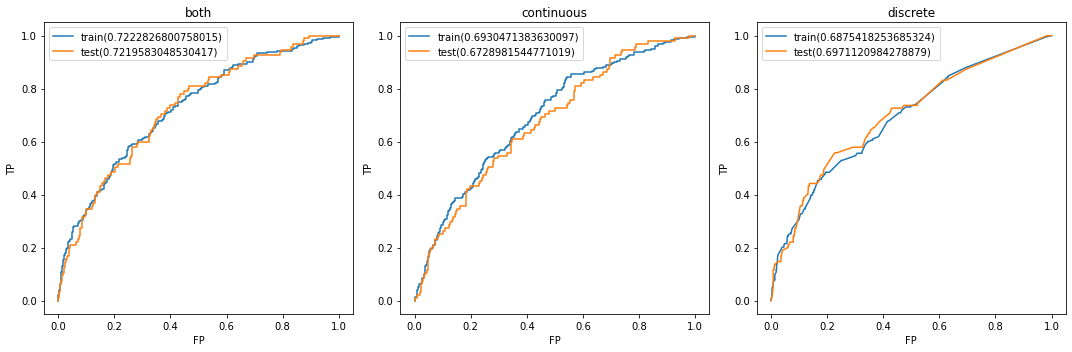

In [46]:
l_label = "Naive Bayes"
titles=["both","continuous","discrete"]
plt.figure(figsize=(3*5,1*5))
for i in range(3):
    labels = train_labels
    plt.subplot(1,3,i+1)
    plt.title(titles[i])

    scores = train_scores[i][:,1]
    score_roc_auc = roc_auc_score(labels, scores)
    fpr, tpr, thresholds = roc_curve(labels, scores)
    plt.plot(fpr, tpr, label=f'train({score_roc_auc})')
    plt.xlabel("FP")
    plt.ylabel("TP")
    plt.legend()

    labels = test_labels
    scores = test_scores[i][:,1]
    score_roc_auc = roc_auc_score(labels, scores)
    fpr, tpr, thresholds = roc_curve(labels, scores)
    plt.plot(fpr, tpr, label=f'test({score_roc_auc})')
    plt.xlabel("FP")
    plt.ylabel("TP")
    plt.legend()

# plt.show()
plt.tight_layout()

In [49]:
!ls

arviz-0.16.1-py3-none-any.whl  medical-rvm-06.ipynb  nb-train.ipynb
dist			       medical-rvm-08.ipynb  svc-rvc-lr-train.ipynb


In [50]:
!zip -r ./nb.zip ./dist/*

  adding: dist/maxvalues.txt (deflated 78%)
  adding: dist/model_lg.model (deflated 30%)
  adding: dist/model_svc_linear.model (deflated 75%)
  adding: dist/model_svc_poly_3.model (deflated 76%)
  adding: dist/model_svc_poly_6.model (deflated 75%)
  adding: dist/model_svc_rbf.model (deflated 75%)
  adding: dist/model_svc_sig.model (deflated 75%)
  adding: dist/p_probas.txt (deflated 8%)
  adding: dist/scaler.pkl (deflated 12%)
  adding: dist/traces_0.npy (deflated 36%)
  adding: dist/traces_1.npy (deflated 35%)
